# Oscar — logistic regression on the Taiwan data

26 Sep 2026. Rough working. A first logistic regression to predict
`default payment next month`, and what its coefficients say about which
columns matter *once the others are known*. This complements `03-predictors`,
which looked at one column at a time.

**What logistic regression does.** It adds the columns up with a weight each,
`z = b0 + b1*x1 + b2*x2 + ...`, and turns that into a probability of default
with the S-shaped curve `p = 1 / (1 + e^-z)`. `z` is the **log-odds** of default,
so a weight `b` means: raising that column by one unit adds `b` to the log-odds,
which multiplies the odds of default by `e^b`.

Step 1 (this notebook so far) is a deliberately simple **baseline**: every
column used as a plain number. Its known weaknesses are listed at the end,
as things to fix next.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve

ROOT = Path.cwd().parent
RAW = ROOT / "data" / "raw"

taiwan = pd.read_excel(RAW / "taiwan-credit-default" / "default of credit card clients.xls",
                       header=1, index_col="ID")
Y = "default payment next month"
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8984"   # no default, default, reference
taiwan.shape

(30000, 24)

## Step 1 — prepare the data

* **Drop exact duplicate rows.** `02-duplicates` found some are probably the
  same customer twice. If one copy lands in the training set and the other in
  the test set, the model is tested on a row it has already seen, which flatters
  the score. That leaves 29,965 rows.
* **Hold out a test set.** Fit on 75% of rows and score on the other 25%,
  which the model never sees. `stratify=y` keeps the 22% default rate the same
  in both parts. `random_state=0` makes the split the same every run.

In [2]:
data = taiwan.drop_duplicates()
X = data.drop(columns=Y)
y = data[Y]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0)

print("train:", X_train.shape, " test:", X_test.shape)
print(f"default rate  train {y_train.mean():.3f}  test {y_test.mean():.3f}")

train: (22473, 23)  test: (7492, 23)
default rate  train 0.221  test 0.221


## Step 2 — fit the model

The columns are on very different scales (`LIMIT_BAL` runs to 1,000,000; `SEX`
is 1 or 2). **`StandardScaler`** rescales each column to mean 0 and standard
deviation (SD) 1. This does two things:

1. the fitting algorithm converges properly, and
2. the coefficients become comparable: each is the change in log-odds for a
   **one-SD** increase in that column, so a bigger size means a bigger effect.

`make_pipeline` chains the scaler and the model. The scaler then learns its
means and SDs from the **training** rows only and reuses them on the test rows,
so no information leaks from the test set. `LogisticRegression` applies a mild
penalty on large weights by default (`C=1.0`), which barely matters with this
many rows.

In [3]:
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)

# predict_proba gives [P(no default), P(default)] per row; keep the second.
p_test = model.predict_proba(X_test)[:, 1]

print(f"test AUC:      {roc_auc_score(y_test, p_test):.3f}")
print(f"test accuracy: {accuracy_score(y_test, p_test > 0.5):.3f}")
print(f"accuracy of always saying 'no default': {1 - y_test.mean():.3f}")

test AUC:      0.720
test accuracy: 0.810
accuracy of always saying 'no default': 0.779


**Reading the scores.**

* **AUC** (area under the ROC curve): pick one defaulter and one non-defaulter
  at random. AUC is the chance the model gives the defaulter the higher risk.
  0.5 is guessing, 1 is perfect.
* **Accuracy** only counts how often `p > 0.5` gets the label right. With 78%
  non-defaulters, "always say no default" already scores 0.78, so accuracy
  barely separates models here. That is a point for `report/04-Evaluation`.

The ROC curve shows every threshold at once. Along the curve, the threshold
moves from "flag nobody" (bottom left) to "flag everybody" (top right).

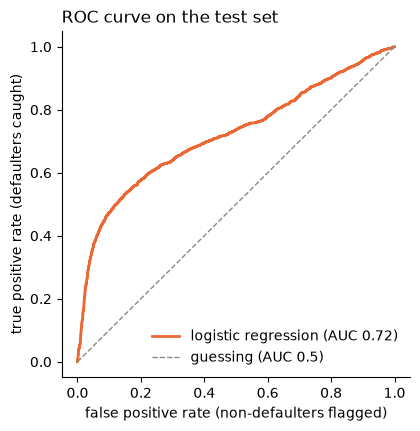

In [4]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
# roc_curve tries every threshold and returns, for each, the share of
# non-defaulters flagged (false positive rate) and of defaulters caught (true positive rate).
fpr, tpr, thresholds = roc_curve(y_test, p_test)
ax.plot(fpr, tpr, color=ORANGE, linewidth=2,
        label=f"logistic regression (AUC {roc_auc_score(y_test, p_test):.2f})")
ax.plot([0, 1], [0, 1], color=GREY, linestyle="--", linewidth=1, label="guessing (AUC 0.5)")
ax.legend(frameon=False, loc="lower right")
ax.set_xlabel("false positive rate (non-defaulters flagged)")
ax.set_ylabel("true positive rate (defaulters caught)")
ax.set_title("ROC curve on the test set", loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## Step 3 — what the coefficients say

Each bar is a column's weight: the change in log-odds of default for a
one-SD increase in that column, **holding all the other columns fixed**.
Orange (positive) means higher values → more likely to default; blue
(negative) means less likely. `e^b` is the factor the odds are multiplied by.

In [5]:
coefs = pd.Series(model[-1].coef_[0], index=X.columns)
coef_table = pd.DataFrame({"coef (per SD)": coefs, "odds multiplier e^coef": np.exp(coefs)})
coef_table.sort_values("coef (per SD)", key=abs, ascending=False).round(3)

,coef (per SD),odds multiplier e^coef
PAY_0,0.642,1.900
BILL_AMT1,-0.304,0.738
PAY_AMT2,-0.256,0.774
PAY_AMT1,-0.179,0.836
BILL_AMT3,0.147,1.158
LIMIT_BAL,-0.119,0.888
PAY_2,0.094,1.098
EDUCATION,-0.093,0.911
MARRIAGE,-0.087,0.917
PAY_3,0.084,1.088


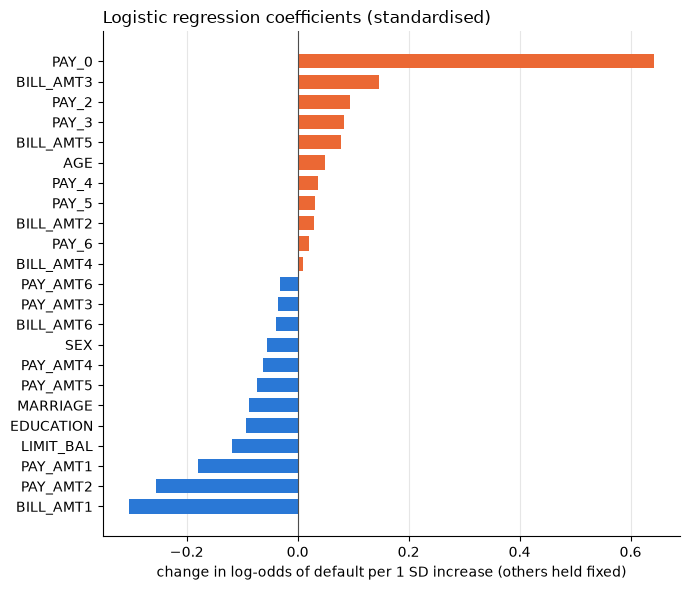

In [6]:
order = coefs.sort_values()
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(order.index, order.values, height=0.7,
        color=[ORANGE if v > 0 else BLUE for v in order.values])
ax.axvline(0, color="0.3", linewidth=0.8)
ax.set_xlabel("change in log-odds of default per 1 SD increase (others held fixed)")
ax.set_title("Logistic regression coefficients (standardised)", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="0.9"); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Notes so far (rough)

* **Scores:** test AUC 0.72. Accuracy is 0.81, against 0.78 for always saying
  "no default", so accuracy makes the model look barely better than doing nothing.
* **`PAY_0` dominates** even with every other column held fixed: one SD later
  on the latest repayment multiplies the odds of default by about 1.9. This
  matches `03-predictors`.
* **Do not read the bill and payment coefficients at face value.** `BILL_AMT1`
  comes out strongly negative and `BILL_AMT3` positive, although the two
  correlate 0.86 (`03-predictors` heatmap). When columns move together, the
  model can trade weight between them almost freely, so single coefficients
  can flip sign. Only their combined effect means something. Possible fixes:
  keep one month, use summaries (average bill, bill / limit), or a stronger
  penalty (smaller `C`, or L1 to drop columns).
* **Known weaknesses of this baseline** (the next steps):
  1. `EDUCATION`, `MARRIAGE` and `SEX` are category codes used as numbers.
     "Education = 4" is not "twice education = 2". These need one-hot encoding
     (one 0/1 column per category), and the undocumented codes merged into "other".
  2. `PAY_*` used as a number assumes each extra month late adds the same
     risk. The `01-working` bar chart shows a jump between 0/-1/-2 and ≥2
     instead. The kink in the ROC curve is likely this. One-hot or grouped
     bins should help.
  3. The money columns are very skewed. `log(1 + x)`, or ratios like
     payment / bill, would suit a linear model better.
* Useful comparison for the group: German Credit scorecards (`report/02`) use
  logistic regression too, after binning. That fixes points 1-3 in one go,
  which is why the industry does it.